In [ ]:
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.decomposition import NMF, PCA
# from sklearn.preprocessing import normalize
# from sklearn.linear_model import LinearRegression
# from sklearn.cluster import KMeans

# from scipy.stats import binom
# from scipy.cluster.hierarchy import to_tree
# from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
# from scipy.spatial.distance import squareform
# from scipy.spatial.distance import pdist

import sys
sys.path.append("../../local_lib/")
from hac2 import HAC
from heatmap import plot_grid, plot_map, CorrelationHeatMap as CHM

In [2]:
px_template = 'plotly_white'
doc_str = 'chunk_str'
token_pattern = r"(?u)\b\w[\w']*\b"
min_ngram = 1
max_ngram = 1

In [3]:
DOC = pd.read_csv("ajtzibab-CHUNK.csv").set_index("chunk_id")

In [48]:
TOKEN = pd.read_csv("ajtzibab-TOKEN.csv").set_index(['para_id','line_id','token_num'])
# VOCAB = pd.read_csv("ajtzibab-VOCAB.csv").set_index("term_str") # We create a new one 

In [5]:
TOKEN

index token_str term_str
para_id line_id token_num                          
0       1       0              0     POPOL    popol
                1              1       WUJ      wuj
        2       0              2      OJER     ojer
                1              3       TAQ      taq
                2              4      TZIJ     tzij
...                          ...       ...      ...
152     11      5          26259   konojel  konojel
        12      0          26260   K'iche'  k'iche'
                1          26261      Sta.      sta
                2          26262      Cruz     cruz
                3          26263    ub'i'.    ub'i'

[26264 rows x 3 columns]

In [ ]:
count_engine = CountVectorizer(ngram_range=(min_ngram, max_ngram), token_pattern=token_pattern)
CTM = pd.DataFrame(count_engine.fit_transform(DOC[doc_str]).toarray(), 
                   index=DOC.index, 
                   columns=count_engine.get_feature_names_out())

In [123]:
VOCAB = CTM.sum().to_frame('n')
VOCAB.index.name = 'term_str'
VOCAB['grams'] = VOCAB.apply(lambda x: len(x.name.split()), axis=1)
VOCAB['p'] = VOCAB.n / VOCAB.n.sum()
VOCAB['i'] = np.log2(1/VOCAB.p)
VOCAB['df'] = CTM.astype(bool).sum()
VOCAB['dp'] = VOCAB.df / len(CTM) 
VOCAB['di'] = np.log2(1/VOCAB.dp)
VOCAB['dh'] = VOCAB.dp * VOCAB.di
VOCAB.sample(10, weights='dh')

,n,grams,p,i,df,dp,di,dh
term_str,,,,,,,,
k'a'm,14,1,0.000533,10.873719,8,0.133333,2.906891,0.387585
oqotal,1,1,0.000038,14.681074,1,0.016667,5.906891,0.098448
chikira,1,1,0.000038,14.681074,1,0.016667,5.906891,0.098448
mu'j,1,1,0.000038,14.681074,1,0.016667,5.906891,0.098448
nima'amaq,7,1,0.000266,11.873719,7,0.116667,3.099536,0.361612
kaminaqil,1,1,0.000038,14.681074,1,0.016667,5.906891,0.098448
rij,41,1,0.001561,9.323522,24,0.400000,1.321928,0.528771
kitz'aqik,2,1,0.000076,13.681074,1,0.016667,5.906891,0.098448
xpetik,5,1,0.000190,12.359146,5,0.083333,3.584963,0.298747


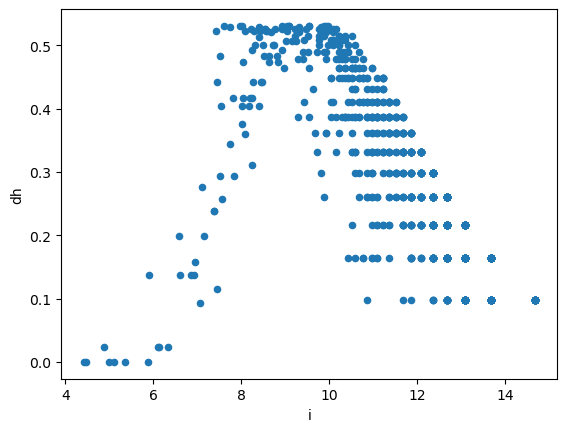

In [125]:
VOCAB.plot.scatter('i', 'dh')
plt.show()

In [127]:
# VOCAB.plot.scatter('i', 'di')
# plt.show()

In [128]:
stop_mask = VOCAB.dh < .2 # 
SIGS = VOCAB[~stop_mask].index.tolist()
stopwords = VOCAB[stop_mask].index.tolist()
len(SIGS)

777

In [129]:
CTMX = CTM[SIGS]
tfidf_engine = TfidfTransformer(norm='l2', use_idf=True, smooth_idf=True)
TFIDF = pd.DataFrame(tfidf_engine.fit_transform(CTMX).toarray(), columns=CTMX.columns, index=CTMX.index)    
TFIDF_SIM = pd.DataFrame(cosine_similarity(TFIDF), index=TFIDF.index)

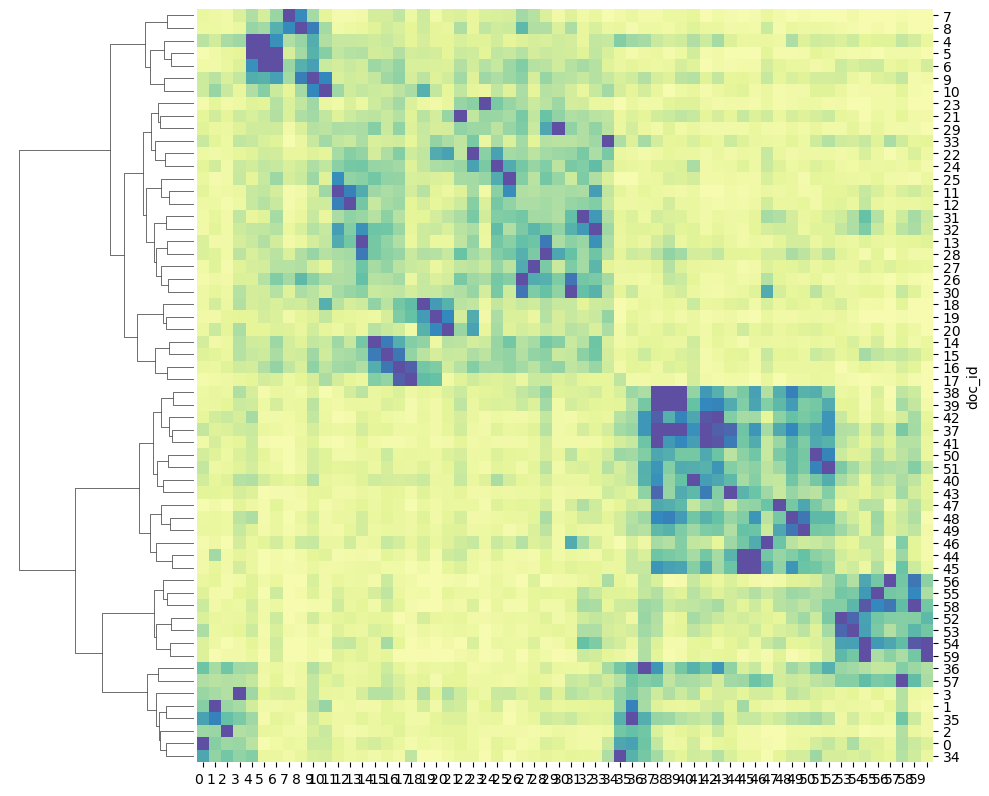

In [130]:
fig = sns.clustermap(TFIDF_SIM, 
               method='ward', metric='euclidean',
               cmap='Spectral', center=0, cbar_pos=None, 
               col_cluster=False, robust=True, 
               xticklabels=True, yticklabels=True)
plt.setp(fig.ax_heatmap.get_xticklabels(), rotation=0, ha="right")
fig.ax_col_dendrogram.set_visible(False)

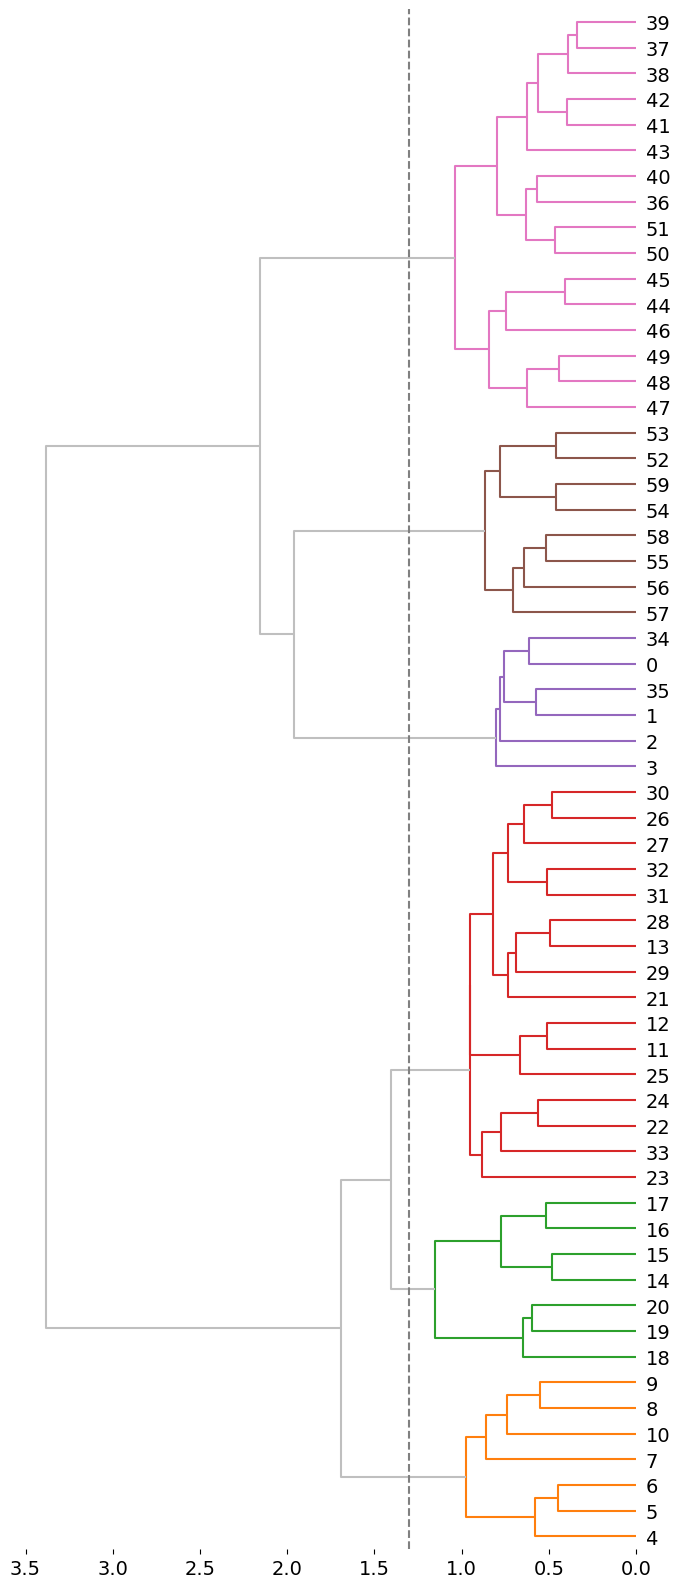

In [131]:
plt.figure(figsize=(8, len(TFIDF_SIM)/3))
tfidf_hac = HAC(TFIDF_SIM)
tfidf_hac.color_thresh = 1.3
tfidf_hac.plot()
sns.despine(left=True, bottom=True)
ax = plt.gca()
ax.axvline(tfidf_hac.color_thresh, c='gray', ls='--')
plt.show()

In [132]:
tfidf_hac.get_cluster_labels()

In [133]:
DOC['hac_label'] = tfidf_hac.CLUSTER_LABELS

In [134]:
k = len(set(tfidf_hac.CLUSTER_LABELS))
k

6

In [135]:
CLUSTER = DOC.hac_label.value_counts().to_frame('n_chunks')

In [136]:
CLUSTER

,n_chunks
hac_label,
2,16
4,16
6,8
1,7
3,7
5,6


In [137]:
label_col = "hac_label"

In [138]:
CLUSTER['gloss'] = TFIDF.join(DOC[label_col]).groupby(label_col).mean().idxmax(1)
CLUSTER['top_terms'] = TFIDF.join(DOC[label_col]).groupby(label_col).mean().apply(lambda x: ', '.join(x.sort_values(ascending=False).head(7).index), axis=1)

In [139]:
CLUSTER.sort_index()

,n_chunks,gloss,top_terms
hac_label,,,
1,7,kaqix,"kaqix, k'ajolab, sipakna, wuqub, ajpu, kab'raq..."
2,16,xib'alb'a,"xib'alb'a, kame, ajpu, xcha, b'a, la, wuqub"
3,7,q'apoj,"q'apoj, che, ati't, b'atz, chowen, kati't, ix"
4,16,b'alam,"b'alam, tojil, amaq, k'itze, q'ij, majukutaj, ..."
5,6,kaj,"kaj, ulew, alom, k'ajolom, tz'aqol, b'itol, winaq"
6,8,ajaw,"ajaw, ajawab, ajpop, k'iche, tinamit, unim, q'..."


In [140]:
# pca_engine = PCA(n_components=k + (k % 2))
n_comps=5
pca_engine = PCA(n_components=n_comps)
PCAX = pd.DataFrame(pca_engine.fit_transform(TFIDF), index=TFIDF.index)
PCAX.index.name = 'doc_id'
LOADINGS = pd.DataFrame(pca_engine.components_.T * np.sqrt(pca_engine.explained_variance_), index = TFIDF.columns)
LOADINGS.index.name = 'term_str'

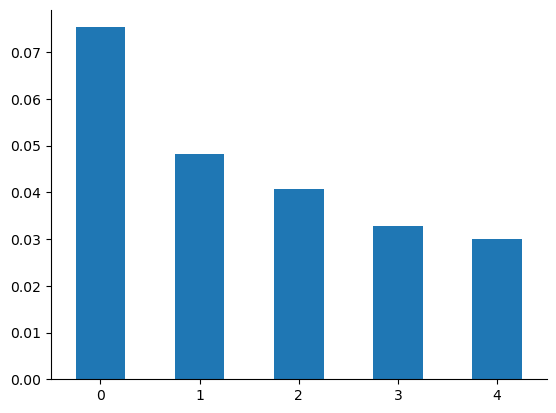

In [141]:
pd.Series(pca_engine.explained_variance_).plot.bar(rot=0)
sns.despine()
plt.show()

In [142]:
X0 = DOC.join(PCAX).join(CLUSTER, on=label_col)

def plot_pca(x, y):

    px.scatter(X0, x, y, 
        text=X0.index, 
        height=850, width=950, 
        color=X0.gloss,
        size = [1 for i in range(len(X0))],
        template=px_template,
        marginal_x='box', 
        marginal_y='box').show()

    quantile = .99
    A = LOADINGS.loc[np.abs(LOADINGS[x]) >= np.abs(LOADINGS[x]).quantile(quantile), x]
    B = LOADINGS.loc[np.abs(LOADINGS[y]) >= np.abs(LOADINGS[y]).quantile(quantile), y]    
    C = pd.concat([A,B], axis=1).index
    
    px.scatter(LOADINGS.loc[C].join(VOCAB), x, y, 
        title=f"Quantile {quantile} Loadings for {x} and {y}",
        opacity=.5,
        text=C, 
        size='n',
        template=px_template,
        height=850, width=950).show()
    

In [143]:
plot_pca(0,1)

In [144]:
# X0

In [145]:
def comp_box(comp_id):
    px.box(X0,
           x=comp_id,
           y='gloss',
           color='gloss', 
           template=px_template,
           # height=400, width=600, 
           title=f'PC {i}').show()

In [146]:
for i in range(n_comps):
    comp_box(i)

In [147]:
n_topic_terms = 10
nmf_engine = NMF(n_components=k, max_iter=5000, init='nndsvda', solver='mu', beta_loss='kullback-leibler')
THETA = pd.DataFrame(nmf_engine.fit_transform(TFIDF), index=TFIDF.index)
THETA_SIM = pd.DataFrame(cosine_similarity(THETA), index=THETA.index, columns=THETA.index)
PHI = pd.DataFrame(nmf_engine.components_, columns=TFIDF.columns)
TOPIC = PHI.T.apply(lambda x: ', '.join(x.sort_values(ascending=False).head(n_topic_terms).index)).T.to_frame('top_terms')
TOPIC.index.name = 'topic_id'
DOC[f'top_topic_{k}'] = THETA.idxmax(1).values

In [148]:
with open("topics.md", "w") as outfile:
    TOPIC.to_markdown(outfile)

In [149]:
TOPIC['gloss'] = PHI.idxmax(1)

In [150]:
TOPIC

,top_terms,gloss
topic_id,,
0,"xib'alb'a, kame, ajpu, xcha, naqi, wuqub, k'aj...",xib'alb'a
1,"b'alam, tojil, amaq, k'itze, majukutaj, aq'ab,...",b'alam
2,"ajaw, ajawab, ajpop, aj, k'iche, tinamit, nim,...",ajaw
3,"kaj, ulew, winaq, uk'u'x, tz'aqol, b'itol, k'a...",kaj
4,"kaqix, k'ajolab, sipakna, wuqub, xcha, kab'raq...",kaqix
5,"kati't, q'apoj, che, chowen, b'atz, ati't, ajp...",kati't


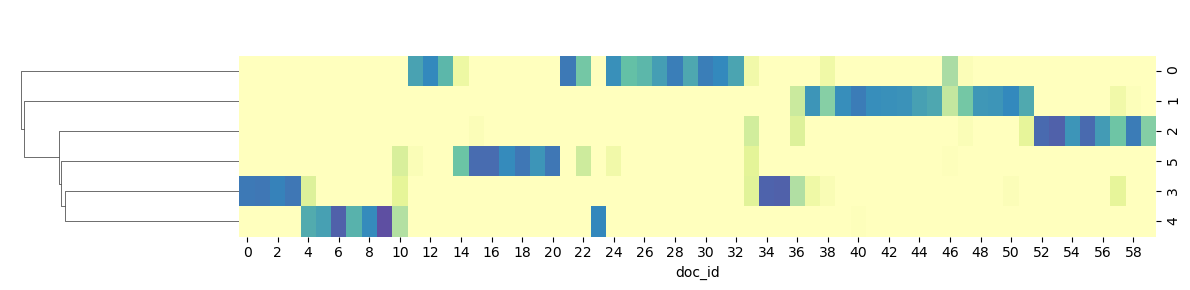

In [151]:
fig = sns.clustermap(THETA.T, 
    cmap='Spectral', 
    center=0, 
    metric='euclidean',
    method='ward', 
    cbar_pos=None,
    row_cluster=True, 
    col_cluster=False,
    figsize=(12,3)
)

In [152]:
R = THETA.T.corr().stack().sort_index().to_frame('r')

In [153]:
R.index.names = ['chunk_id_tmp', 'chunk_id']

In [154]:
RDIFF = R.query("chunk_id == chunk_id_tmp + 1") #.plot.barh(figsize=(2,10), legend=False);
RDIFF = RDIFF.reset_index().set_index('chunk_id').drop(columns=['chunk_id_tmp'])

In [155]:
RDIFF.style.bar()

,r
chunk_id,
1,1.000000
2,1.000000
3,1.000000
4,0.141725
5,0.941561
6,1.000000
7,1.000000
8,1.000000
9,1.000000


In [156]:
RDIFF2 = RDIFF.join(RDIFF.shift(-1), rsuffix='_next').join(RDIFF.shift(), rsuffix='_prev')
RDIFF2['novelty'] = RDIFF2.r - RDIFF2.r_prev
RDIFF2['transience'] = RDIFF2.r - RDIFF2.r_next
RDIFF2['resonance'] = (RDIFF2.novelty * RDIFF2.transience)

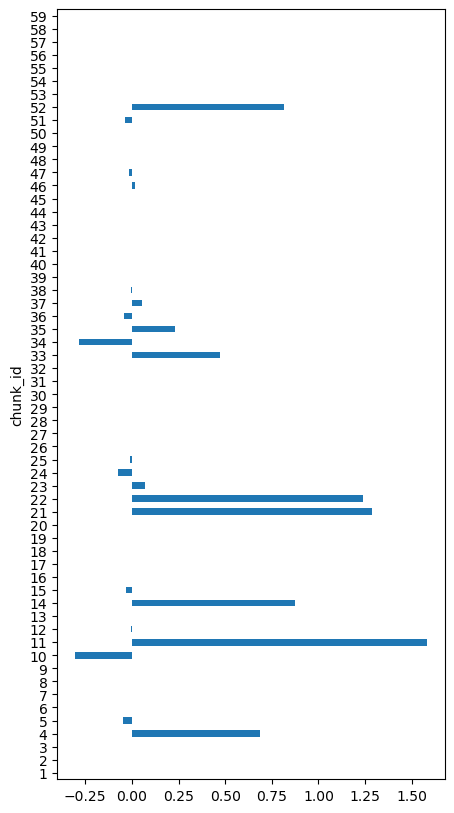

In [157]:
RDIFF2.resonance.plot.barh(figsize=(5,10));